In [6]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import pandas as pd
import os

from numpy import pi

# Parâmetros do sistema
Kp = np.float32(208.1420263238445)
ap = np.float32(6.734006734006734)

# Amplitude do degrau (Va)
Va = 5.5

# Constante para converter o valor 
# de RPM para graus
RPM_PARA_GRAUS = 6

# Simulação da saída em RPM

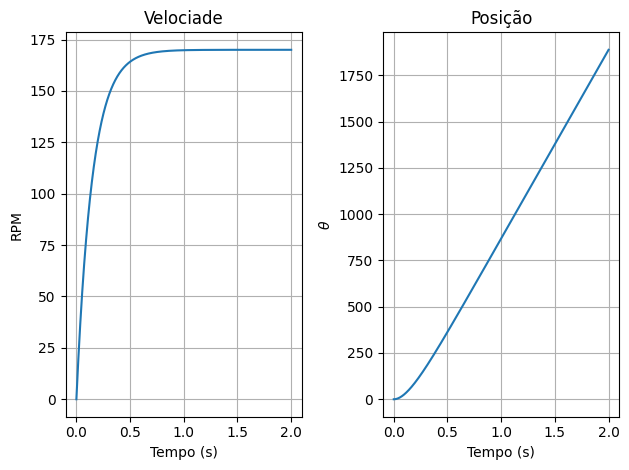

In [9]:
# =================
# SIMULACAO da SAIDA (RPM)
# =================
Ts = 0.001
Tfinal = 2
N = int(Tfinal / Ts)

t = np.linspace(0, Tfinal, N)
y = np.zeros(N)
u = np.ones(N) * Va #V 
theta = np.zeros(N)

for k in range(N - 1):
    # velocidade
    y[k+1] = y[k] + Ts * (-ap * y[k] + Kp * u[k])

    theta[k+1] = theta[k] + Ts * (RPM_PARA_GRAUS * y[k])

plt.subplot(121)
plt.plot(t, y)
plt.xlabel('Tempo (s)')
plt.ylabel('RPM')
plt.title('Velociade')
plt.grid()

plt.subplot(122)
plt.plot(t, theta)
plt.xlabel('Tempo (s)')
plt.ylabel(r'$\theta$')
plt.title('Posição')
plt.grid()

plt.tight_layout()

plt.show()

# Ganho de realimentação 

## Parâmetros do controlador

In [11]:
# Overshoot
Mp = 5 / 100

# Tempo de acomodação de 2%
ts2 = 0.45

# Coeficiente de amortecimento
zeta = np.sqrt((np.log(Mp)**2) / (np.pi**2 + np.log(Mp)**2))

# Frequencia natural do sistema
wm = 4 / (ts2*zeta)

print(f'Mp = {Mp}')
print(f'ts (2%) = {ts2}')
print(f'Zeta = {zeta}')
print(f'wm (rad/s) = {wm}')

real = zeta*wm
imag = wm*np.sqrt(1-zeta**2)

polos = np.array([-real+imag*1j, -real-imag*1j, -real*4])

print(f'polos = {polos}')

Mp = 0.05
ts (2%) = 0.45
Zeta = 0.6901067305598216
wm (rad/s) = 12.880455290847738
polos = [ -8.88888889+9.32168348j  -8.88888889-9.32168348j
 -35.55555556+0.j        ]
